Investigating the statistical integrety of data:

1. Stationarity - Augmented Dickey-Fuller (ADF) test:

- Test for the presence of a unit root
- null hypothesis is that a unit rot is present (non-stationarity)
- alt. hypothesis is that the series is stationary
- if the test yields a small p-value, the null hypothesis is rejected (time series is stationary)
- p-value must be less than the significance level in order to reject the null hypothesis.

Unit root: Y(t)=Y(t-1) + X(e) + e
- if the auto regressive co-efficient of Y(t-1) equals 1.
- the series has a persistent random walk component.
- shocks don't die out they accumulate.
In plain language: if alpha is 0.5 the y(t-1) will become smaller and smaller with every iteration and eventually fade away. But if it is 1, the time series remembers the past with every iteration.

ADF test:
- tests the lag y variable, higher order auto-regressive process in the model.

Python implementation:
Libraries: statsmodel, adfuller(), statsmodels.tsa.stattools
https://www.machinelearningplus.com/time-series/augmented-dickey-fuller-test/

Theoratical foundations:
https://doi.org/10.1016/0165-1765(92)90022-Q

2. Correlations:
- Eliminate higly correlated features.
- from higly correlated features, remove the feature with the least variance.

3. Variance:
- remove low variance features.

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#from fracdiff import fracdiff
from statsmodels.tsa.stattools import adfuller
from scipy.stats import skew, kurtosis
from sklearn.feature_selection import mutual_info_classif
import os

In [45]:
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

# Calculate the threshold
threshold = 0.30 # drop features with more than threshold% missing values


# Data import:
factor = pd.read_csv("featureset.csv", parse_dates=['Date'])
factor = factor.set_index('Date')
missing_factors = factor.isnull().mean()  # fraction of missing values per column
data = factor.loc[:, missing_factors <= threshold]
"""
features = pd.read_csv("labeled_relative_factor_returns.csv", parse_dates=['Date'])
features = features.set_index('Date')
missing_features = features.isnull().mean()  # fraction of missing values per column
df_features = features.loc[:, missing_features <= threshold]

curve = pd.read_csv("curve_features.csv", parse_dates=['Date'])
curve = curve.set_index('Date')
missing_curve = curve.isnull().mean()  # fraction of missing values per column
df_curve = curve.loc[:, missing_curve <= threshold]

vol = pd.read_csv("volatility_features.csv", parse_dates=['Date'])
vol = vol.set_index('Date')
missing_vol = vol.isnull().mean()  # fraction of missing values per column
df_vol = vol.loc[:, missing_vol <= threshold]


data = pd.concat([df_features,df_curve,df_vol], axis=1, join='inner')

"""

# Drop columns with more than 30% missing values


#data = data.dropna()
#data_clipped = data.clip(lower=-1e6, upper=1e6)
print(data)

            VolTermStructPC1  VolTermStructPC2  VolSpread6M  VIX.Index  \
Date                                                                     
2000-01-03               NaN               NaN          NaN        NaN   
2000-01-10               NaN               NaN          NaN        NaN   
2000-01-17               NaN               NaN          NaN        NaN   
2000-01-24               NaN               NaN          NaN        NaN   
2000-01-31               NaN               NaN          NaN        NaN   
...                      ...               ...          ...        ...   
2025-09-08         37.060287         -9.982172   -33.815691      15.18   
2025-09-15         36.512768        -10.204352   -34.046979      14.76   
2025-09-22         37.380050         -9.970643   -32.652140      15.45   
2025-09-29         38.147255         -9.774878   -18.300384      16.12   
2025-10-06         38.773707         -9.941707   -13.628348      16.37   

            VIX3M.Index  VIX6M.Index 

In [46]:
def diagnose_features(df, target=None, corr_thresh=0.70, var_thresh=1e-5):

    report = {}

    # Correlation check 
    var =df.var()
    valid_cols = var[var >= var_thresh].index
    #corr = df.corr()
    corr = df[valid_cols].corr()
    
    high_corr_pairs = []
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i, j]) > corr_thresh:
                high_corr_pairs.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))
    report["high_correlations"] = high_corr_pairs

    # Plot heatmap
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Feature Correlation Heatmap")
    plt.show()

    # Stationarity (ADF test)
    stationarity = {}
    for col in df.columns:
        try:
            result = adfuller(df[col].dropna())
            stationarity[col] = {"p-value": result[1], "stationary": result[1] < 0.05}
        except Exception as e:
            stationarity[col] = {"error": str(e)}
    report["stationarity"] = stationarity

    # Variance
    low_var = df.var()[df.var() < var_thresh]
    report["low_variance"] = low_var.index.tolist()


    # Skewness & Kurtosis
    moments = {}
    low_var_cols = df.var()[df.var() < var_thresh].index  # reuse low variance check
    for col in df.columns:
        if col in low_var_cols:
            moments[col] = {"skew": np.nan, "kurtosis": np.nan}
        else:
            series = df[col].dropna()
            s = skew(series, nan_policy="omit")
            k = kurtosis(series, nan_policy="omit")
            moments[col] = {"skew": s, "kurtosis": k}
    report["moments"] = moments

    # Mutual information
    if target is not None:
        X = df.values
        y = target.values
        mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)
        mi_scores = dict(zip(df.columns, mi))
        report["mutual_information"] = dict(sorted(mi_scores.items(), key=lambda x: x[1], reverse=True))

    return report


In [47]:
# Dataframe clean up:
def clean_features(report, df, var_thresh=1e-5):
    # Drop low variance first
    low_var = report["low_variance"]
    cleaned = df.drop(columns=low_var, errors="ignore")

    # Drop one feature from each high correlation pair
    to_drop_corr = set()
    for col1, col2, _ in report["high_correlations"]:
        if col1 in cleaned.columns and col2 in cleaned.columns:
            # Compare variance of the two
            var1 = cleaned[col1].var()
            var2 = cleaned[col2].var()
            if var1 >= var2:
                to_drop_corr.add(col2)  # drop lower variance
            else:
                to_drop_corr.add(col1)

    cleaned = cleaned.drop(columns=to_drop_corr, errors="ignore")
    return cleaned

def split_stationarity(report, df_clean):
    non_stationary = [
        col for col, stats in report["stationarity"].items()
        if isinstance(stats, dict) and not stats.get("stationary", False) and col in df_clean.columns
    ]
    stationary = [col for col in df_clean.columns if col not in non_stationary]

    return df_clean[stationary], df_clean[non_stationary]


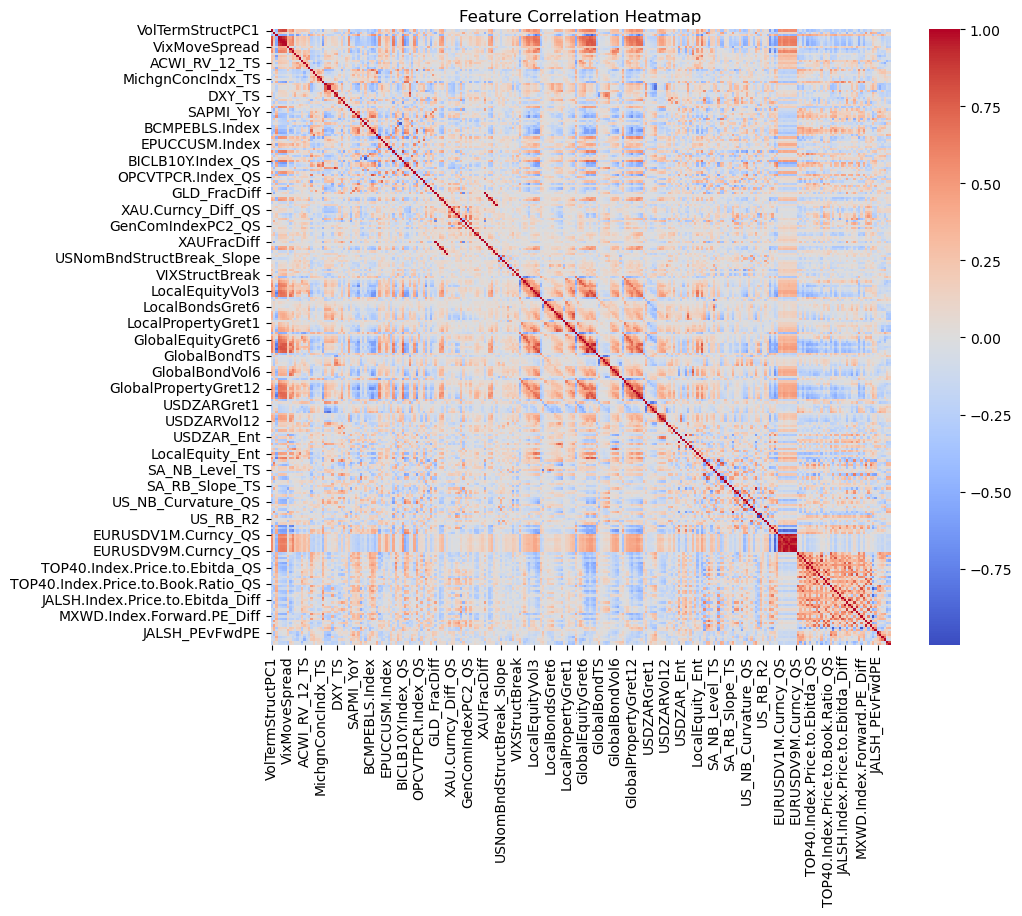

Original features: 270
After cleaning: 155
Stationary features: 131
Non-stationary features: 24


In [48]:
# Diagnose
report = diagnose_features(data)

# Clean features (low variance + high correlation with variance rule)
df_clean = clean_features(report, data)

# Split into stationary / non-stationary
df_stationary, df_nonstationary = split_stationarity(report, df_clean)

print("Original features:", data.shape[1])
print("After cleaning:", df_clean.shape[1])
print("Stationary features:", df_stationary.shape[1])
print("Non-stationary features:", df_nonstationary.shape[1])


Correct for non-stationary features:
1. Simple and log differencing:

2. Z-score transformations:

3. Fractional differencing:

In [49]:
# Extract non-stationary features from diagnostics report, excluding low-variance columns.

def get_nonstationary_features(report, df, var_thresh=1e-5):

    # Get non-stationary features:
    non_stationary = [
        col for col, stats in report["stationarity"].items()
        if isinstance(stats, dict) and not stats.get("stationary", False)
    ]

    # Drop low variance columns:
    low_var = report["low_variance"]
    non_stationary = [col for col in non_stationary if col not in low_var]

    # Drop one feature from each high-correlation pair
    high_corr_pairs = report["high_correlations"]
    to_drop_corr = set()
    for col1, col2, _ in high_corr_pairs:
        # Keep first, drop second (arbitrary but consistent)
        if col2 in non_stationary:
            to_drop_corr.add(col2)
    non_stationary = [col for col in non_stationary if col not in to_drop_corr]


    # Return DataFrame subset:
    return df[non_stationary]




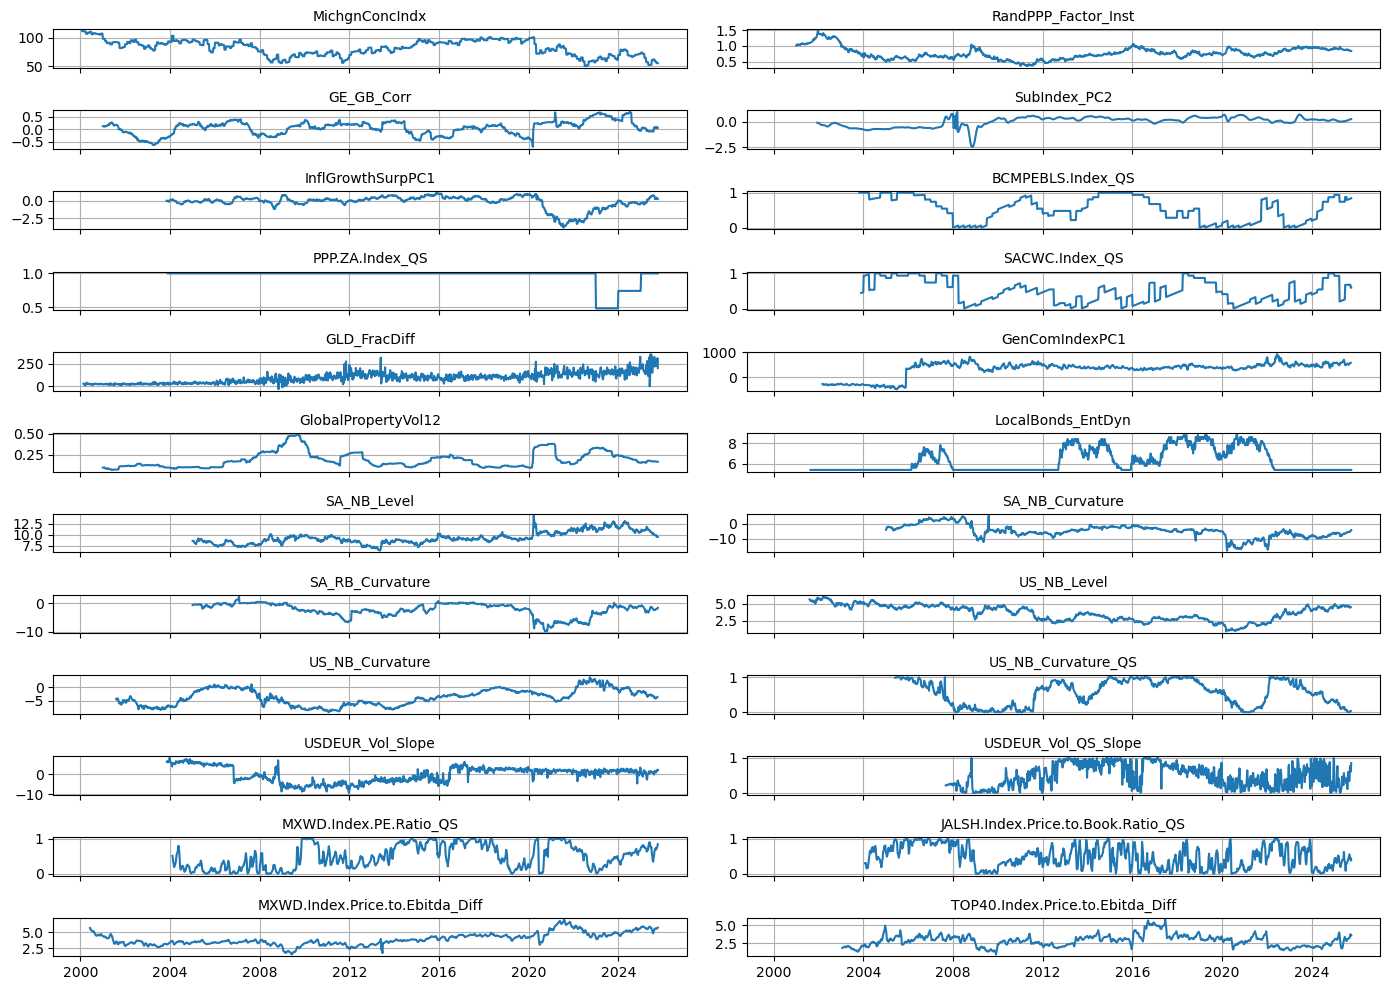

In [50]:
import matplotlib.pyplot as plt

def plot_nonstationary_features(df_nonstationary, ncols=2, figsize=(14, 10)):

    n_features = df_nonstationary.shape[1]
    nrows = int(np.ceil(n_features / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True)
    axes = axes.flatten()

    for i, col in enumerate(df_nonstationary.columns):
        axes[i].plot(df_nonstationary.index, df_nonstationary[col])
        axes[i].set_title(col, fontsize=10)
        axes[i].grid(True)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

plot_nonstationary_features(df_nonstationary)

In [51]:
# Simple differencing:
def diff_transform(series, periods=12): # 12 periods is roughly 3 months 
    return series.diff(periods=periods)

# Log differencing:
def logdiff_transform(series, periods=12):
    return np.log(series).diff(periods=periods)

# Rolling z-score normalization:
def zscore_transform(series, window=12):
    rolling_mean = series.rolling(window).mean()
    rolling_std = series.rolling(window).std()
    return (series - rolling_mean) / rolling_std

# Fractional differencing
#def fracdiff_transform(series, d=0.5):
#    fd_series, _ = fracdiff(series.dropna(), d=d)
#    return fd_series.reindex(series.index)



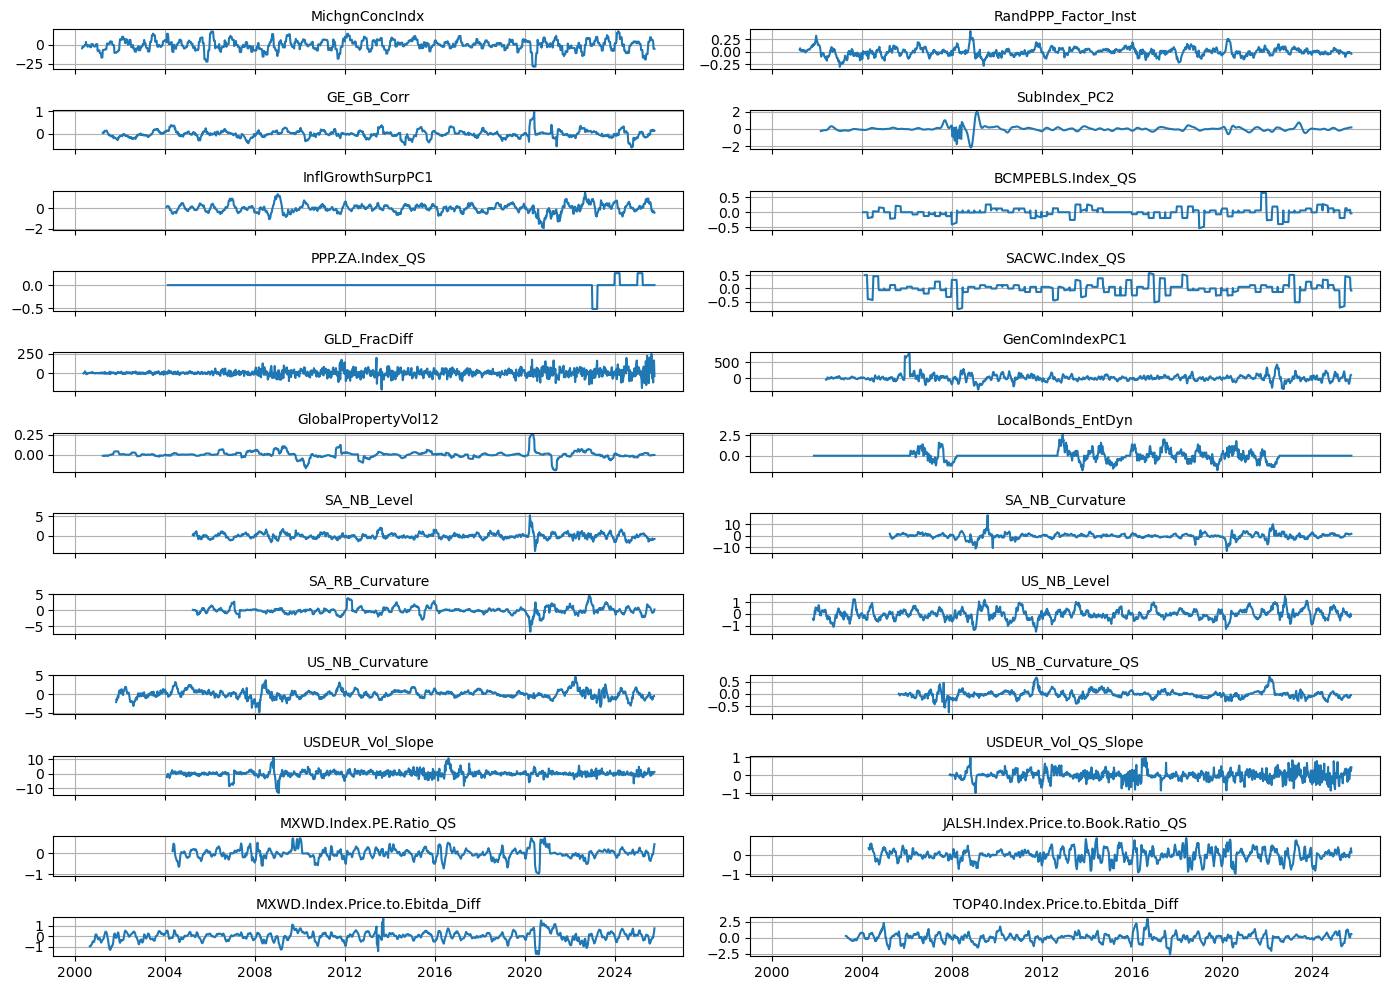

In [52]:
df_zscores = diff_transform(df_nonstationary)

plot_nonstationary_features(df_zscores)

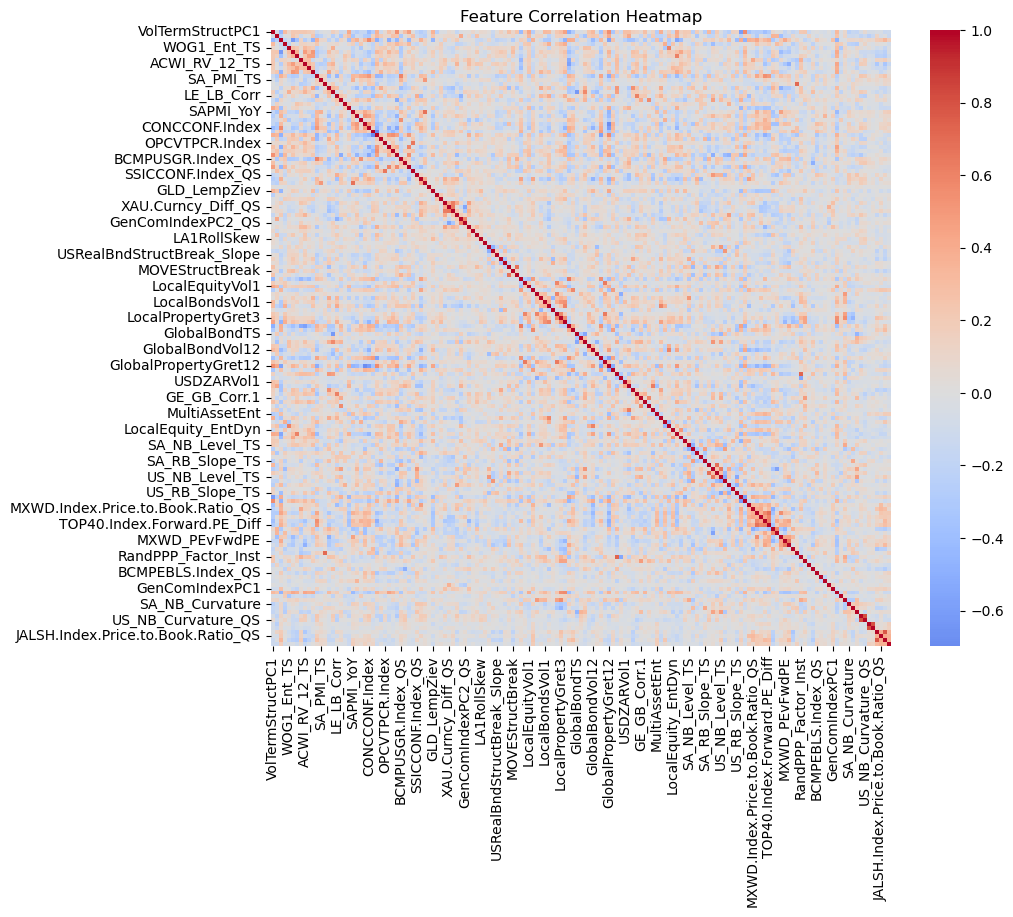

Original features: 155
Stationary features: 155
Non-stationary features: 0


In [53]:
features = pd.concat([df_stationary,df_zscores], axis=1, join='inner')
#features = df_zscores

# Diagnose:
report = diagnose_features(features)

# Clean features (low variance + high correlation with variance rule)
#clean_features = clean_features(report, features)

# Split into stationary / non-stationary
features_stationary, features_nonstationary = split_stationarity(report, features)


print("Original features:", features.shape[1])
#print("After cleaning:", clean_features.shape[1])
print("Stationary features:", features_stationary.shape[1])
print("Non-stationary features:", features_nonstationary.shape[1])


In [54]:
# Save output into csv file:
def lag_features(df, lag=4):

    df_lagged = df.shift(lag)
    return df_lagged.dropna() 

final_features = lag_features(features)

print(final_features)

            VolTermStructPC1  VolTermStructPC2  VolSpread6M  VixMoveSpread  \
Date                                                                         
2007-12-24         54.667071          6.714434    -5.453601      -0.175095   
2007-12-31         47.225471          7.627395   -11.466974      -1.091631   
2008-01-07         42.884690          7.643859   -14.259287      -1.125420   
2008-01-14         48.764285          6.600146   -14.413760      -1.071053   
2008-01-21         40.911327          8.278144   -18.672726      -1.931358   
...                      ...               ...          ...            ...   
2025-09-08         37.194561         -9.918624   -36.750511      -0.223585   
2025-09-15         37.072572         -9.977012   -36.523507      -0.147890   
2025-09-22         35.927867        -10.372554   -35.955053      -0.295999   
2025-09-29         37.239381         -9.968107   -33.647827      -0.205332   
2025-10-06         37.060287         -9.982172   -33.815691     

In [55]:
final_features.to_csv('final_features.csv', index=True)